In [1]:
#Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#loading Dataset
df = pd.read_excel("dataset -P667.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [3]:
#Checking Dataset Shape
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1440, 3)


In [4]:
#Column names
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['title', 'rating', 'body'], dtype='object')


In [5]:
#Printing dataset info
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [6]:
#Checking Missing Values
df.isnull().sum()

,0
title,0
rating,0
body,0


In [7]:
#Checking Duplicate Values
df.duplicated().sum()

np.int64(0)

The dataset contains no missing values and no duplicate records,indicating good initial data quality for analysis.

In [8]:
#Exploring unique ratings
df['rating'].unique()

array([1, 3, 4, 5, 2])

In [9]:
# Rating value count
df['rating'].value_counts().sort_index()

,count
rating,
1,386
2,126
3,199
4,310
5,419


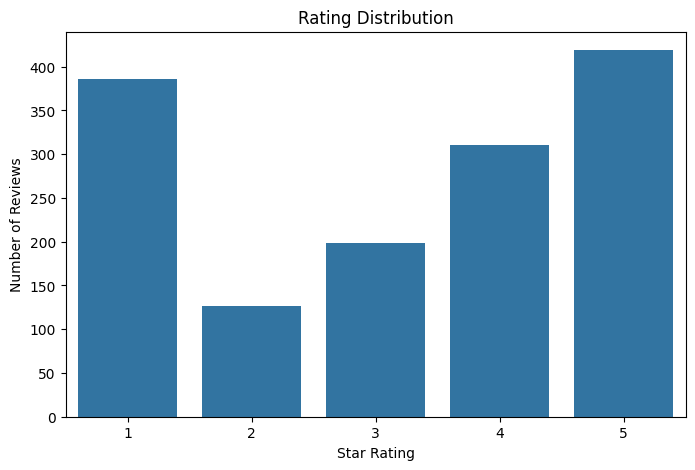

In [10]:
# Rating distribution plot
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

- Ratings range from 1 to 5 stars.
- 5-star reviews are the highest, while 1-star reviews are also significant.
- This indicates both positive and negative sentiments are present in the dataset.

In [11]:
# Creating Review Length Features
df['char_count'] = df['body'].astype(str).apply(len)
df['word_count'] = df['body'].astype(str).apply(lambda x: len(x.split()))
df.head()

,title,rating,body,char_count,word_count
0,Horrible product,1,Very disappointed with the overall performance...,59,8
1,Camera quality is not like 48 megapixel,3,Camera quality is low,21,4
2,Overall,4,"Got the mobile on the launch date,Battery must...",403,66
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,377,67
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",179,29


In [12]:
# Summary Statistics of Review Length
df[['char_count', 'word_count']].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,1440.0,302.109028,225.733052,4.0,170.0,246.0,359.00,2490.0
word_count,1440.0,52.892361,39.346259,1.0,29.0,43.0,63.25,385.0


- Reviews are moderately detailed on average.
- Some reviews are very long, indicating users shared detailed experiences.
- This is useful for sentiment analysis because longer reviews carry richer context.

In [13]:
# Average Review Length by Rating
df.groupby('rating')['word_count'].mean()

,word_count
rating,
1,52.264249
2,51.674603
3,56.527638
4,56.632258
5,49.343675


- Mid-range ratings (3 and 4 stars) contain longer reviews on average.
- 5-star reviews are shorter, likely brief positive feedback.
- Low ratings often include detailed complaints.

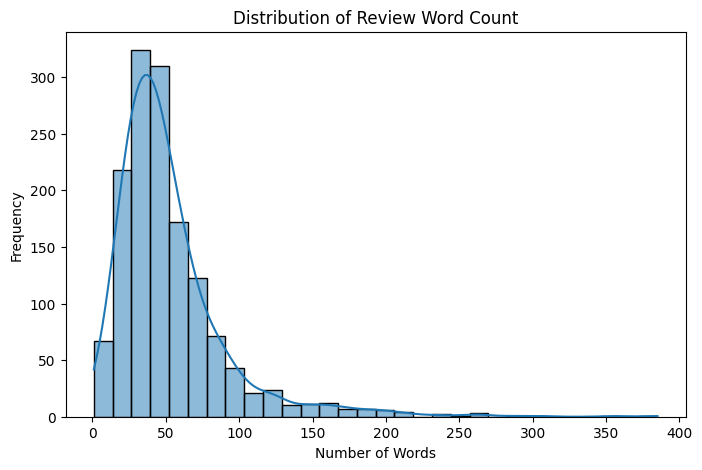

In [14]:
# Distribution of Review Word Count Plot
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Distribution of Review Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

- Most reviews contain around 20–60 words, indicating moderately detailed customer feedback.
- A smaller number of reviews are much longer, showing detailed user experiences.

In [15]:
#Combining Title and Body into Full Review
df['full_review'] = df['title'].astype(str) + " " + df['body'].astype(str)
df[['title', 'body', 'full_review']].head()

,title,body,full_review
0,Horrible product,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


Title and body were combined to create a complete review text containing both summary and detailed customer feedback.

In [16]:
# Displaying Sample Full Review Text
print(df['full_review'][0])

Horrible product Very disappointed with the overall performance from Samsung


In [17]:
# Importing NLP Preprocessing Libraries
import re
import nltk
from nltk.corpus import stopwords

In [18]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
# Displaying Cleaned Review Samples
stop_words = set(stopwords.words('english'))  # Creates a set of common english stopwords like is, the, and, of

def clean_text(text):
    text = text.lower() #convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) #Removes numbers , symbols, punctuations
    words = text.split() #splits into words
    words = [word for word in words if word not in stop_words] #Removes common stopwords and keeps meaningful words only
    return " ".join(words) #Joins remaining words back into a sentence

df['clean_review'] = df['full_review'].apply(clean_text)
df[['full_review', 'clean_review']].head()

,full_review,clean_review
0,Horrible product Very disappointed with the ov...,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel Camera...,camera quality like megapixel camera quality low
2,"Overall Got the mobile on the launch date,Batt...",overall got mobile launch datebattery must app...
3,A big no from me 1. It doesn't work with 5.0GH...,big doesnt work ghz wifi frequency ghz old sch...
4,Put your money somewhere else Not worth buying...,put money somewhere else worth buyingfaulty so...


In [20]:
# Most Frequent Words in Reviews
from collections import Counter

all_words = " ".join(df['clean_review']).split()
word_freq = Counter(all_words)

top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
top_words

,Word,Frequency
0,phone,1787
1,good,1356
2,camera,957
3,battery,805
4,samsung,747
5,quality,695
6,mobile,588
7,price,437
8,product,412
9,buy,336


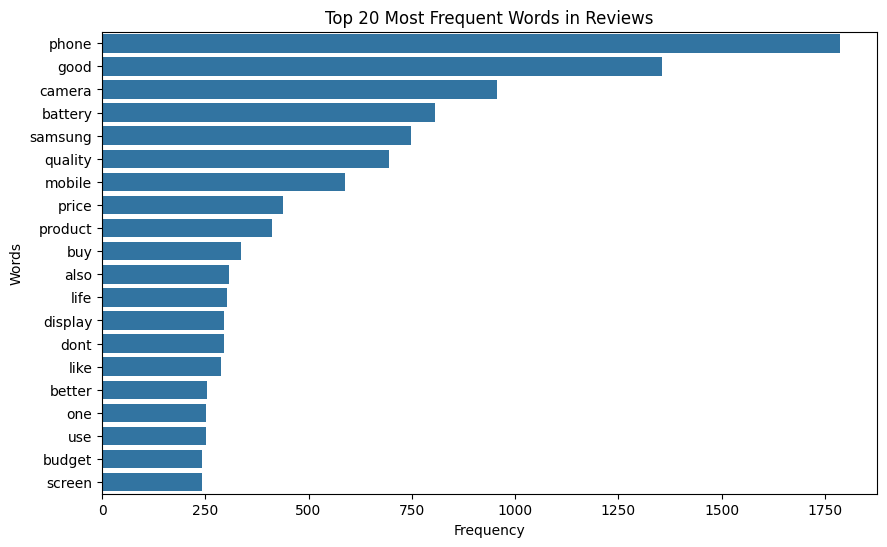

In [21]:
# Visualizing Top Frequent Words
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Word', data=top_words)
plt.title("Top 20 Most Frequent Words in Reviews")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

- Customers frequently discuss camera, battery, display, and price.
- These appear to be the most important product decision factors.
- Positive words like 'good' also occur often.

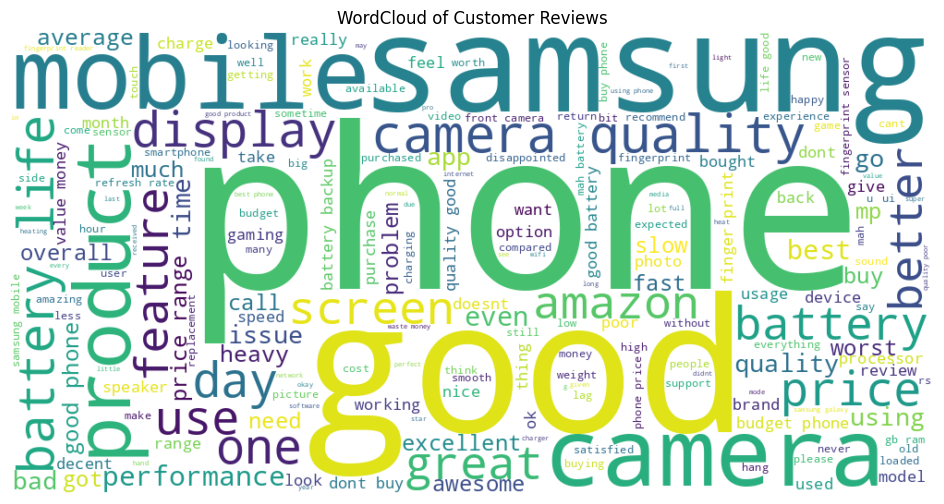

In [22]:
# Generating WordCloud of Reviews
text = " ".join(df['clean_review'])

wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Customer Reviews")
plt.show()

The WordCloud highlights the most frequently mentioned terms in customer reviews, helping identify key product features and customer concerns.

In [23]:
# Creating Sentiment Labels from Ratings
def get_sentiment(rating):
    if rating in [4, 5]:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(get_sentiment)
df[['rating', 'sentiment']].head()

,rating,sentiment
0,1,Negative
1,3,Neutral
2,4,Positive
3,1,Negative
4,1,Negative


In [24]:
# Sentiment Distribution Count
df['sentiment'].value_counts()

,count
sentiment,
Positive,729
Negative,512
Neutral,199


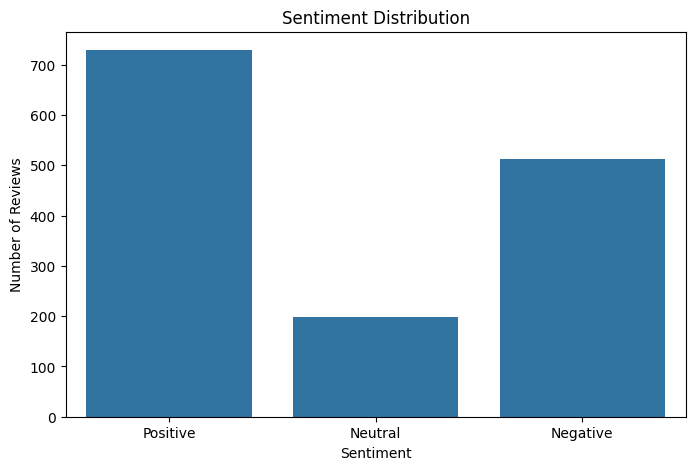

In [25]:
# Visualizing Sentiment Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, order=['Positive','Neutral','Negative'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

- Positive reviews are highest, indicating overall customer satisfaction.
- However, negative reviews are also substantial, suggesting improvement areas exist.

In [26]:
# Top Words in Positive Reviews
positive_text = " ".join(df[df['sentiment']=='Positive']['clean_review'])
positive_words = Counter(positive_text.split())

top_positive = pd.DataFrame(positive_words.most_common(15), columns=['Word','Frequency'])
top_positive

,Word,Frequency
0,good,993
1,phone,923
2,battery,542
3,camera,532
4,quality,334
5,price,322
6,samsung,299
7,life,217
8,mobile,213
9,budget,207


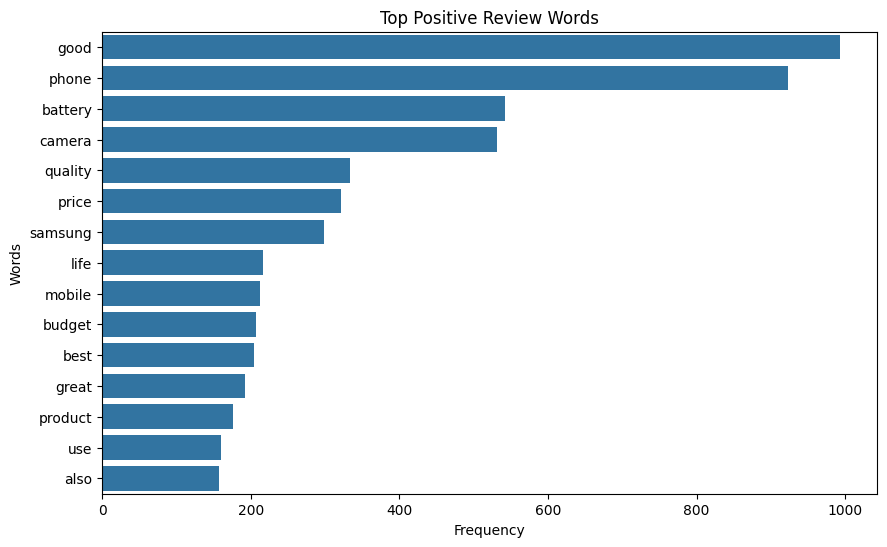

In [27]:
# Visualizing Positive Review Keywords
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Word', data=top_positive)
plt.title("Top Positive Review Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [28]:
#Top Words in Positive Reviews

negative_text = " ".join(df[df['sentiment']=='Negative']['clean_review'])
negative_words = Counter(negative_text.split())

top_negative = pd.DataFrame(negative_words.most_common(15), columns=['Word','Frequency'])
top_negative

,Word,Frequency
0,phone,609
1,samsung,357
2,mobile,279
3,camera,262
4,quality,243
5,buy,212
6,product,211
7,dont,191
8,worst,183
9,good,173


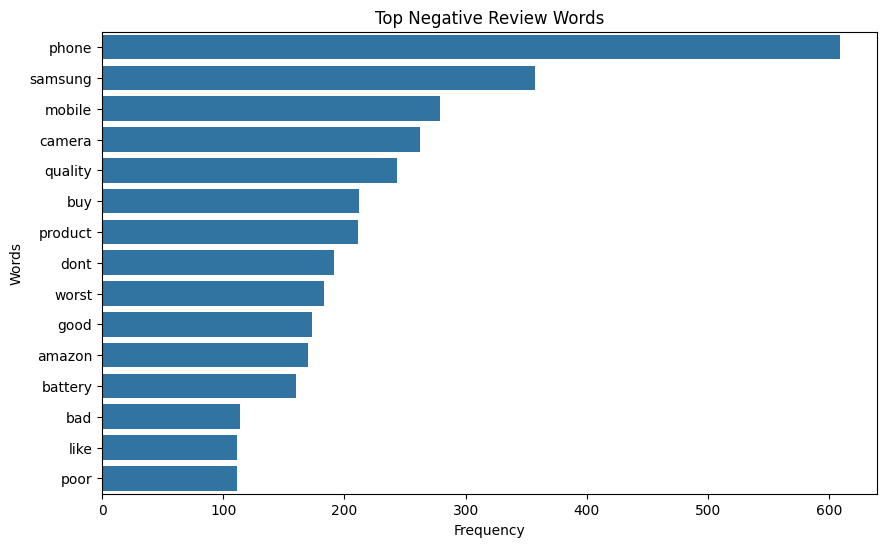

In [29]:
# Visualizing Negative Review Keywords
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Word', data=top_negative)
plt.title("Top Negative Review Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [30]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,729
Negative,512
Neutral,199


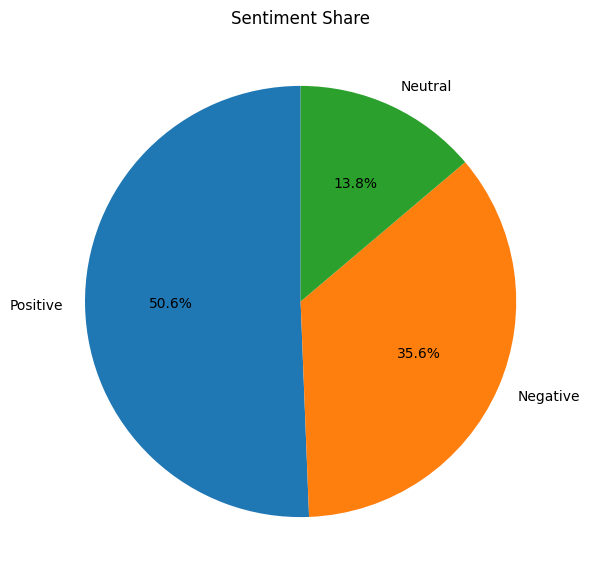

In [31]:
# Sentiment Share Pie Chart
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Sentiment Share")
plt.show()

In [32]:
print("Final EDA Insights:")
print("- Dataset contains 1440 customer reviews with rating and review text.")
print("- No missing values or duplicate records were found.")
print("- Majority of reviews are Positive, followed by Negative and Neutral.")
print("- Customers frequently discuss battery, camera, display, price, and quality.")
print("- Positive reviews praise battery life, camera, and value for money.")
print("- Negative reviews highlight poor quality, bad experience, and feature issues.")
print("- Battery and camera are major factors influencing customer sentiment.")

Final EDA Insights:
- Dataset contains 1440 customer reviews with rating and review text.
- No missing values or duplicate records were found.
- Majority of reviews are Positive, followed by Negative and Neutral.
- Customers frequently discuss battery, camera, display, price, and quality.
- Positive reviews praise battery life, camera, and value for money.
- Negative reviews highlight poor quality, bad experience, and feature issues.
- Battery and camera are major factors influencing customer sentiment.


In [33]:
df.head()

,title,rating,body,char_count,word_count,full_review,clean_review,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,59,8,Horrible product Very disappointed with the ov...,horrible product disappointed overall performa...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,21,4,Camera quality is not like 48 megapixel Camera...,camera quality like megapixel camera quality low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",403,66,"Overall Got the mobile on the launch date,Batt...",overall got mobile launch datebattery must app...,Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,377,67,A big no from me 1. It doesn't work with 5.0GH...,big doesnt work ghz wifi frequency ghz old sch...,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",179,29,Put your money somewhere else Not worth buying...,put money somewhere else worth buyingfaulty so...,Negative


In [34]:
# Train Test Split for Machine Learning
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size :", X_test.shape)

Training Size: (1152,)
Testing Size : (288,)


The dataset was divided into training and testing sets using an 80:20 ratio to evaluate model performance on unseen data.

In [35]:
# Convert Text into Numerical Features using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Learn vocabulary from training data and convert text into numerical form
X_train_tfidf = tfidf.fit_transform(X_train)

# Convert test data using same learned vocabulary
X_test_tfidf = tfidf.transform(X_test)

# Display shape of transformed datasets
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape :", X_test_tfidf.shape)

Training TF-IDF Shape: (1152, 5000)
Testing TF-IDF Shape : (288, 5000)


In [52]:
predi = tfidf.transform(['Absolute ; " ? piece human of waste'])

In [53]:
predi_df=pd.DataFrame(predi.toarray(), columns=tfidf.get_feature_names_out())
predi_df.head()

,aa,aap,abide,able,abruptly,absence,absentresolution,absolute,absolutely,abt,...,youre,youth,youthis,youtube,youtubedo,youtubers,yrs,zero,zoom,zooming
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.698746,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
x_train_df = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())
x_train_df.head()

,aa,aap,abide,able,abruptly,absence,absentresolution,absolute,absolutely,abt,...,youre,youth,youthis,youtube,youtubedo,youtubers,yrs,zero,zoom,zooming
0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.198435,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.122352,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- Text reviews were converted into numerical TF-IDF vectors using the top 5000 important terms.
- This allows machine learning models to process textual data.

In [37]:
# Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Initialize model
lr_model = LogisticRegression(max_iter=1000)

# Train model on training data
lr_model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test_tfidf)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

# Display accuracy
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7777777777777778


In [62]:
lr_model.classes_

array(['Negative', 'Neutral', 'Positive'], dtype=object)

In [58]:
#prediction
predicted=lr_model.predict(predi)
predicted

array(['Negative'], dtype=object)

In [61]:
predicted[0]

'Negative'

In [64]:
probability = lr_model.predict_proba(predi)
probability

array([[0.72637675, 0.09842957, 0.17519368]])

In [38]:
# Classification Report for Logistic Regression

# Display detailed performance metrics
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    Negative       0.79      0.83      0.81       102
     Neutral       0.40      0.05      0.09        40
    Positive       0.78      0.94      0.85       146

    accuracy                           0.78       288
   macro avg       0.66      0.61      0.58       288
weighted avg       0.73      0.78      0.73       288



- The model performs well on Positive and Negative classes, with F1-scores of 0.85 and 0.81 respectively.
- However, the Neutral class is harder to classify, with a low F1-score of 0.09 and recall of 0.05, likely due to fewer samples (40 reviews).

In [39]:
# Train Naive Bayes Model

from sklearn.naive_bayes import MultinomialNB

# Initialize model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_nb = nb_model.predict(X_test_tfidf)

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

# Display accuracy
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.7152777777777778


In [40]:
# Train Support Vector Machine (SVM) Model

from sklearn.svm import LinearSVC

# Initialize model
svm_model = LinearSVC()

# Train model
svm_model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

# Display accuracy
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7743055555555556


In [41]:
# Compare Accuracy of All Models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [lr_accuracy, nb_accuracy, svm_accuracy]
})

print(results.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
0  Logistic Regression  0.777778
2                  SVM  0.774306
1          Naive Bayes  0.715278


- Logistic Regression achieved the highest overall accuracy, followed closely by SVM.
- Naive Bayes showed comparatively lower performance.

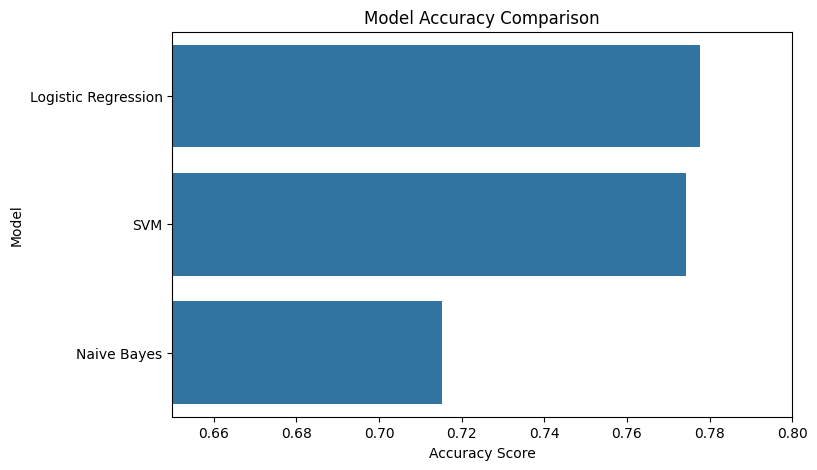

In [42]:
# Visualize Model Accuracy Comparison

plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=results.sort_values(by='Accuracy', ascending=False))
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy Score")
plt.ylabel("Model")
plt.xlim(0.65, 0.80)
plt.show()

In [43]:
# Final Model Selection Summary

print("Final Model Comparison:")
print("- Logistic Regression Accuracy :", lr_accuracy)
print("- Naive Bayes Accuracy         :", nb_accuracy)
print("- SVM Accuracy                :", svm_accuracy)

print("\nBest Performing Model: Logistic Regression")
print("Reason: Highest accuracy among 3 tested models.")

Final Model Comparison:
- Logistic Regression Accuracy : 0.7777777777777778
- Naive Bayes Accuracy         : 0.7152777777777778
- SVM Accuracy                : 0.7743055555555556

Best Performing Model: Logistic Regression
Reason: Highest accuracy among 3 tested models.


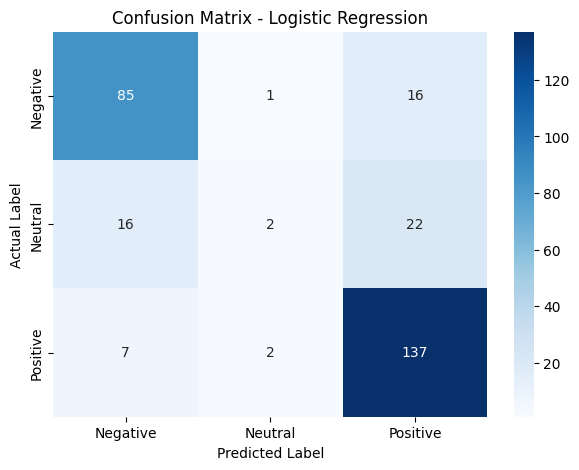

In [44]:
# Confusion Matrix for Best Model (Logistic Regression)

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

- The confusion matrix shows most Positive and Negative reviews were predicted correctly, while Neutral reviews were often misclassified.
- This indicates Neutral sentiment is harder to identify.

In [65]:
import pickle

In [66]:
tf_file='tfidf.pkl'
log_file='logreg.pkl'

In [70]:
pickle.dump(tfidf,open(tf_file,'wb'))
pickle.dump(lr_model,open(log_file,'wb'))